# 04 — Order Payments: EDA & Preprocessing
**Owner:** Member D

### Member D Responsibilities

*   **Raw Tables Responsibility:** `order_payments` + final merge of all four pieces.
*   **Stage 3 Tasks:** Understand, inspect, make clean-data decisions, perform EDA, analyze relationships and outliers, and document findings.
*   **Stage 4 Tasks:** Handle preprocessing, perform feature engineering, aggregate data at the order level, and merge all processed datasets.
*   **Final Output:** Produce `payments_clean.csv` and final merged train/test datasets.
*   **Grain of Output:** One row per `order_id`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Loading Raw Data

In [2]:
# Load olist_order_payments_dataset.csv
payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')

print('Payments head:')
display(payments.head())

Payments head:


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


## 2. Basic Structure and Data Types

In [3]:
print('Payments shape:', payments.shape)
print('\nPayments info:')
payments.info()

print('\nPayments descriptive statistics:')
display(payments.describe(include='all'))

print('\nColumn names:')
print(payments.columns.tolist())

Payments shape: (103886, 5)

Payments info:
<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 8.1 MB

Payments descriptive statistics:


,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500



Column names:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


## 3. Uniqueness and Key Checks

In [4]:
print('Payment rows:', len(payments))
print('Unique orders:', payments["order_id"].nunique())
print('Unique payment sequential values:', payments["payment_sequential"].nunique())
print('Unique payment types:', payments["payment_type"].nunique())

# Check how many orders have multiple payment methods
payments_per_order = payments.groupby("order_id").size()
print('\nOrders with multiple payment methods:', (payments_per_order > 1).sum())
print('Orders with single payment method:', (payments_per_order == 1).sum())
print('Maximum payment methods per order:', payments_per_order.max())

Payment rows: 103886
Unique orders: 99440
Unique payment sequential values: 29
Unique payment types: 5

Orders with multiple payment methods: 2961
Orders with single payment method: 96479
Maximum payment methods per order: 29


## 4. Missing-Value Analysis

In [5]:
def missing_summary(df):
    result = pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing %": df.isnull().mean() * 100
    })
    return result[result["Missing Count"] > 0].sort_values(
        "Missing %", ascending=False
    )

print('Missing values in payments:')
display(missing_summary(payments))

# Check for any zero values that might indicate missing data
print('\nZero values analysis:')
print('Zero payment_value:', (payments['payment_value'] == 0).sum())
print('Zero payment_installments:', (payments['payment_installments'] == 0).sum())

Missing values in payments:


,Missing Count,Missing %



Zero values analysis:
Zero payment_value: 9
Zero payment_installments: 2


## 5. Duplicate Analysis

In [6]:
print("Duplicate payment rows:", payments.duplicated().sum())
print("Duplicate order-payment keys:",
      payments.duplicated(subset=["order_id", "payment_sequential"]).sum())

# Check for any completely identical payment records
print("\nSample of orders with multiple payment methods:")
multi_payment_orders = payments_per_order[payments_per_order > 1].head(5)
print(multi_payment_orders.index.tolist())
display(payments[payments['order_id'].isin(multi_payment_orders.index)].head(10))

Duplicate payment rows: 0
Duplicate order-payment keys: 0

Sample of orders with multiple payment methods:
['0016dfedd97fc2950e388d2971d718c7', '002f19a65a2ddd70a090297872e6d64e', '0071ee2429bc1efdc43aa3e073a5290e', '009ac365164f8e06f59d18a08045f6c4', '00b4a910f64f24dbcac04fe54088a443']


,order_id,payment_sequential,payment_type,payment_installments,payment_value
285,009ac365164f8e06f59d18a08045f6c4,5,voucher,1,8.75
10244,0071ee2429bc1efdc43aa3e073a5290e,1,voucher,1,100.00
12874,00b4a910f64f24dbcac04fe54088a443,2,voucher,1,48.05
15298,009ac365164f8e06f59d18a08045f6c4,6,voucher,1,4.17
16053,009ac365164f8e06f59d18a08045f6c4,1,credit_card,1,0.88
16459,009ac365164f8e06f59d18a08045f6c4,2,voucher,1,4.50
20036,002f19a65a2ddd70a090297872e6d64e,1,voucher,1,44.11
30155,0071ee2429bc1efdc43aa3e073a5290e,2,voucher,1,92.44
32058,009ac365164f8e06f59d18a08045f6c4,4,voucher,1,5.45
59042,00b4a910f64f24dbcac04fe54088a443,1,credit_card,1,2.54


## 6. Invalid-Value Checks

In [7]:
print("Negative payment values:", (payments["payment_value"] < 0).sum())
print("Negative installments:", (payments["payment_installments"] < 0).sum())
print("Negative payment sequential:", (payments["payment_sequential"] < 0).sum())

# Check for unreasonable installment values
print("\nInstallments > 24:", (payments["payment_installments"] > 24).sum())
print("Installments = 0:", (payments["payment_installments"] == 0).sum())

# Check for extremely high payment values
print("\nPayment value > 10,000:", (payments["payment_value"] > 10000).sum())
print("Payment value > 5,000:", (payments["payment_value"] > 5000).sum())

Negative payment values: 0
Negative installments: 0
Negative payment sequential: 0

Installments > 24: 0
Installments = 0: 2

Payment value > 10,000: 1
Payment value > 5,000: 6


## 7. EDA – Payment Type Distribution

Payment type distribution:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Payment type percentages:
payment_type
credit_card    73.922376
boleto         19.043952
voucher         5.558978
debit_card      1.471806
not_defined     0.002888
Name: proportion, dtype: float64


C:\Users\SKY PC\AppData\Local\Temp\ipykernel_4980\2878423244.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_type_counts.index, y=payment_type_counts.values, palette='viridis')


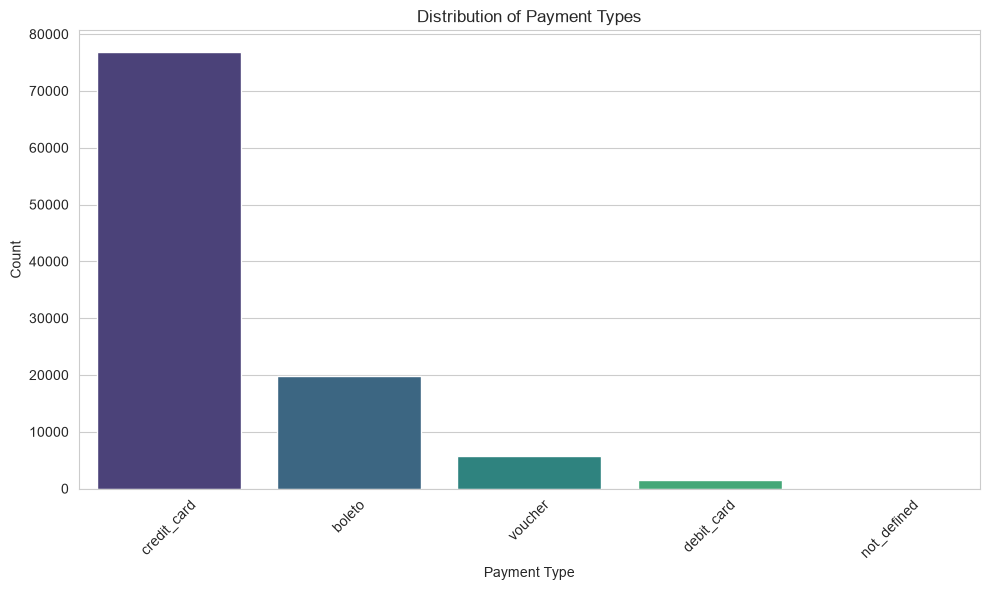

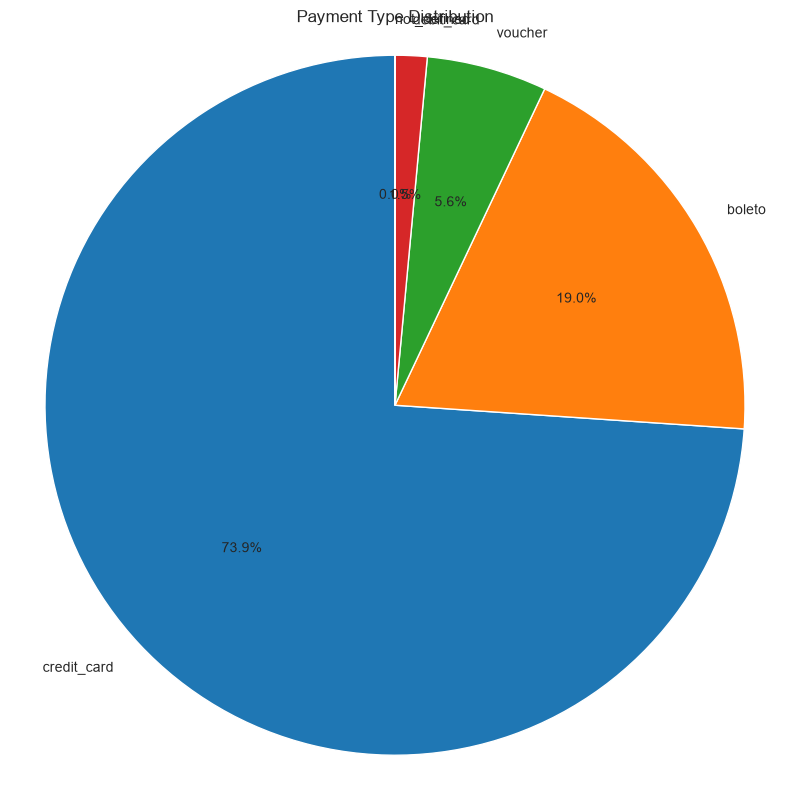

In [8]:
payment_type_counts = payments['payment_type'].value_counts()
payment_type_pct = payments['payment_type'].value_counts(normalize=True) * 100

print('Payment type distribution:')
print(payment_type_counts)
print('\nPayment type percentages:')
print(payment_type_pct)

plt.figure(figsize=(10, 6))
sns.barplot(x=payment_type_counts.index, y=payment_type_counts.values, palette='viridis')
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.pie(payment_type_counts.values, labels=payment_type_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Payment Type Distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()

## 8. EDA – Payment Installments Distribution

Payment installments distribution:
count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64


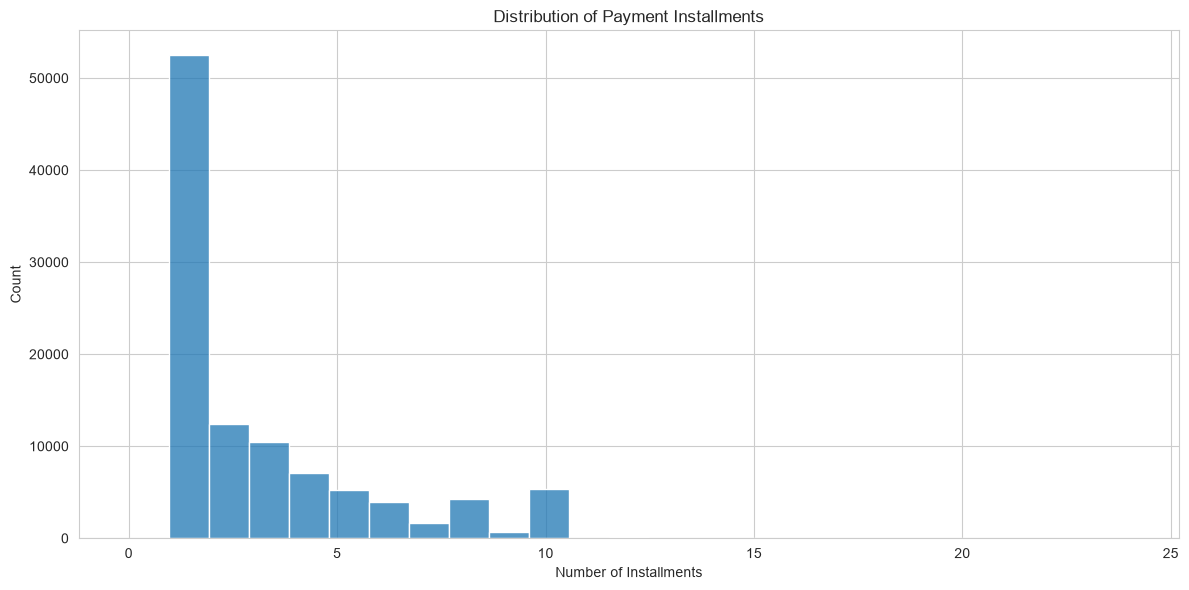

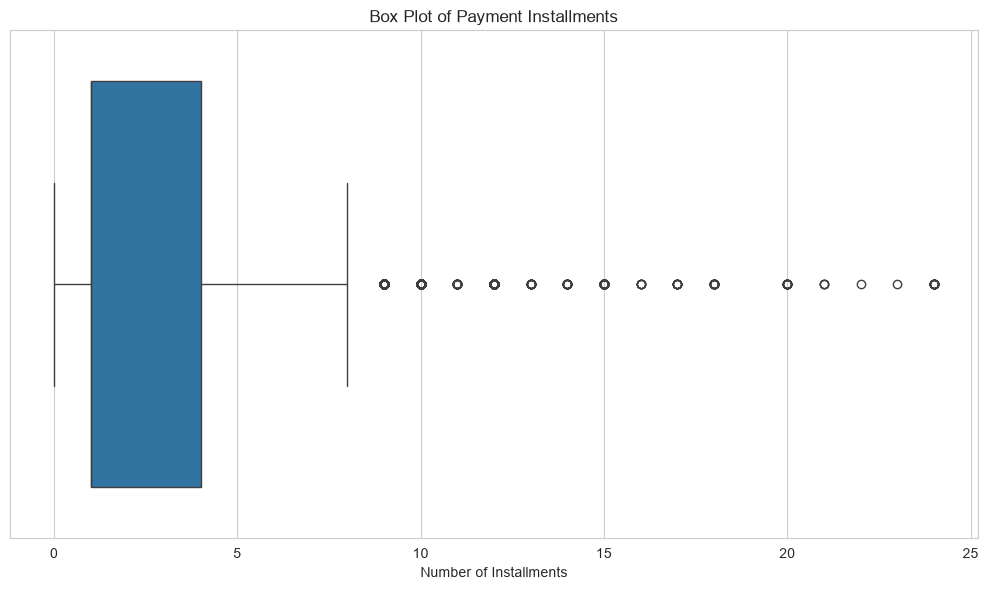


Installments by payment type:


,count,mean,std,min,25%,50%,75%,max
payment_type,,,,,,,,
boleto,19784.0,1.000000,0.00000,1.0,1.0,1.0,1.0,1.0
credit_card,76795.0,3.507155,2.85099,0.0,1.0,3.0,5.0,24.0
debit_card,1529.0,1.000000,0.00000,1.0,1.0,1.0,1.0,1.0
not_defined,3.0,1.000000,0.00000,1.0,1.0,1.0,1.0,1.0
voucher,5775.0,1.000000,0.00000,1.0,1.0,1.0,1.0,1.0


In [9]:
print('Payment installments distribution:')
print(payments['payment_installments'].describe())

plt.figure(figsize=(12, 6))
sns.histplot(payments['payment_installments'], bins=25, kde=False)
plt.title('Distribution of Payment Installments')
plt.xlabel('Number of Installments')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=payments['payment_installments'])
plt.title('Box Plot of Payment Installments')
plt.xlabel('Number of Installments')
plt.tight_layout()
plt.show()

# Analyze installments by payment type
print('\nInstallments by payment type:')
installments_by_type = payments.groupby('payment_type')['payment_installments'].describe()
display(installments_by_type)

## 9. EDA – Payment Value Distribution

Payment value distribution:
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

Payment value skewness: 9.25400952847806
Payment value kurtosis: 241.82844191450522


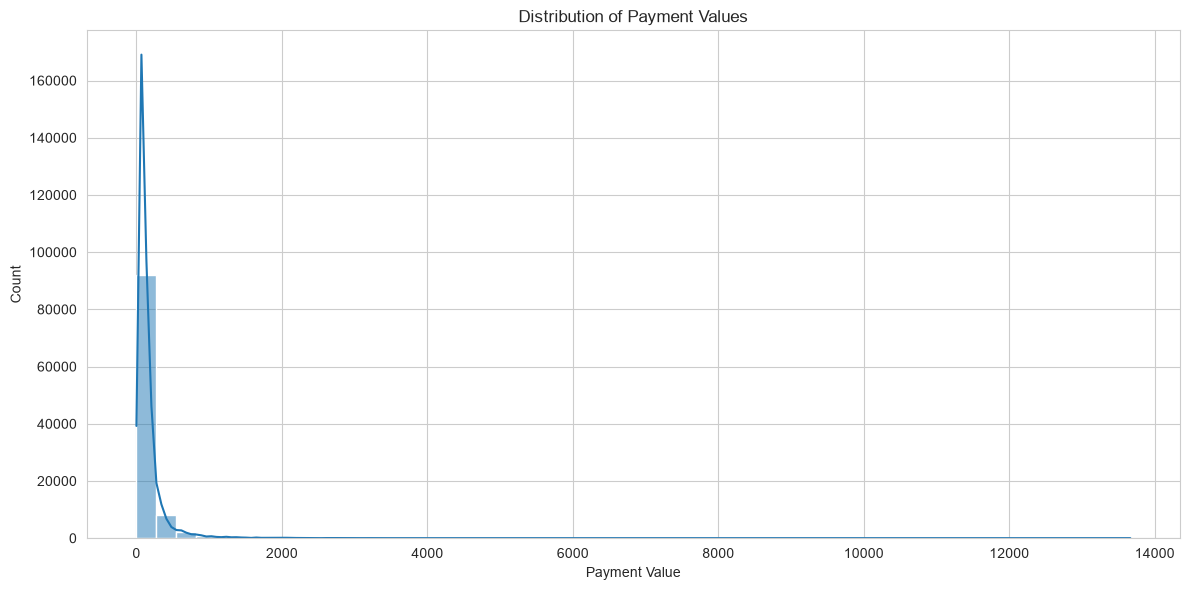

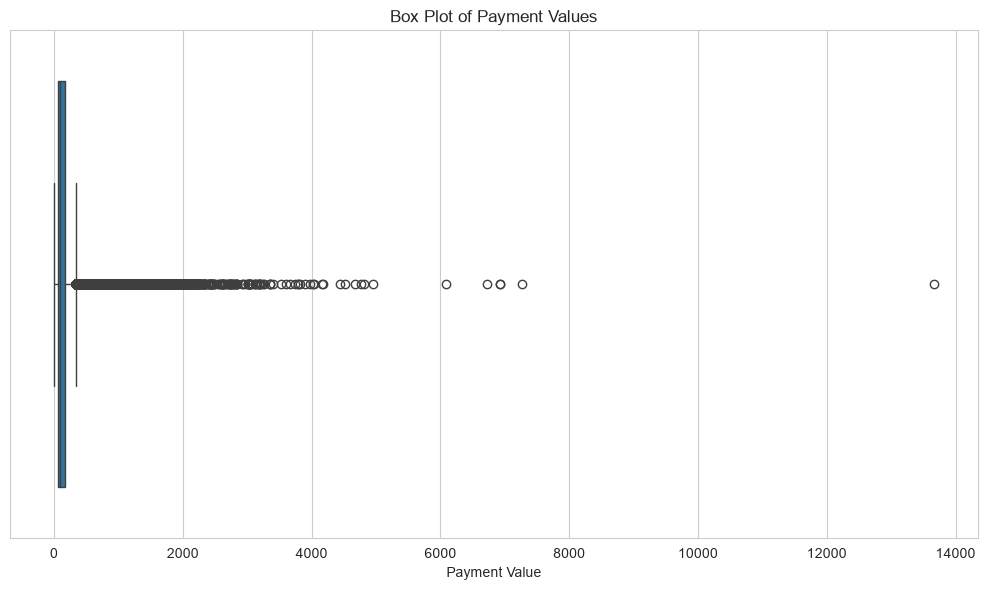

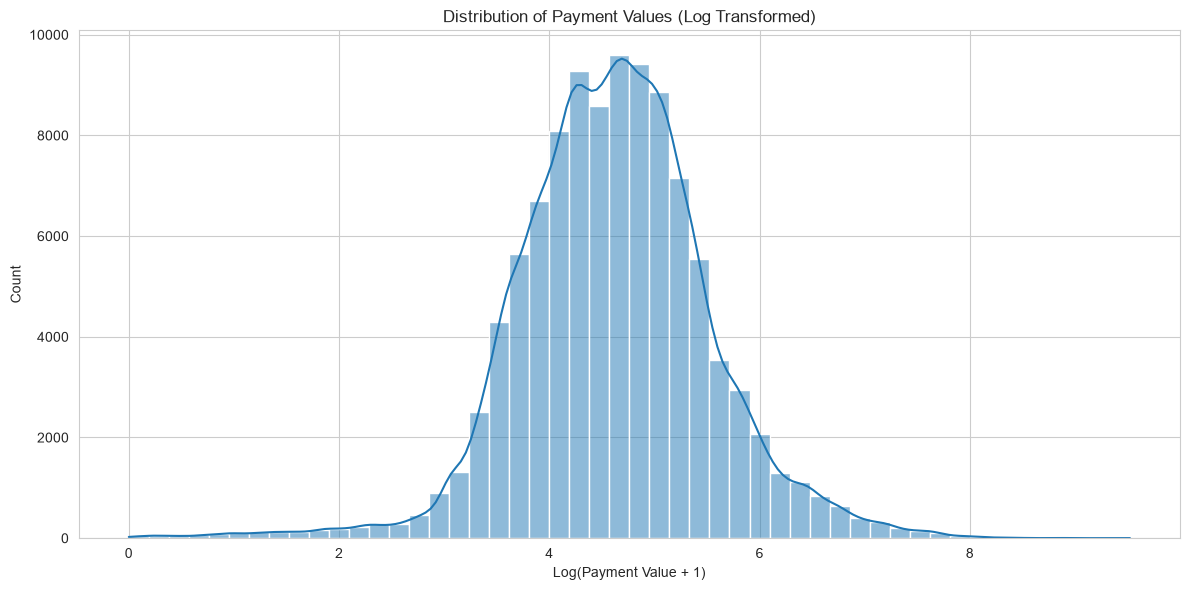

In [10]:
print('Payment value distribution:')
print(payments['payment_value'].describe())

print('\nPayment value skewness:', payments['payment_value'].skew())
print('Payment value kurtosis:', payments['payment_value'].kurtosis())

plt.figure(figsize=(12, 6))
sns.histplot(payments['payment_value'], bins=50, kde=True)
plt.title('Distribution of Payment Values')
plt.xlabel('Payment Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=payments['payment_value'])
plt.title('Box Plot of Payment Values')
plt.xlabel('Payment Value')
plt.tight_layout()
plt.show()

# Log transformation to handle skewness
plt.figure(figsize=(12, 6))
sns.histplot(np.log1p(payments['payment_value']), bins=50, kde=True)
plt.title('Distribution of Payment Values (Log Transformed)')
plt.xlabel('Log(Payment Value + 1)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 10. EDA – Payment Value by Payment Type

Payment value statistics by payment type:


,count,mean,std,min,25%,50%,75%,max
payment_type,,,,,,,,
boleto,19784.0,145.034435,213.581061,11.62,55.5225,93.89,160.7625,7274.88
credit_card,76795.0,163.319021,222.119311,0.01,62.2100,106.87,181.2100,13664.08
debit_card,1529.0,142.570170,245.793401,13.38,51.1000,89.30,154.3200,4445.50
not_defined,3.0,0.000000,0.000000,0.00,0.0000,0.00,0.0000,0.00
voucher,5775.0,65.703354,115.519185,0.00,18.0350,39.28,80.0000,3184.34


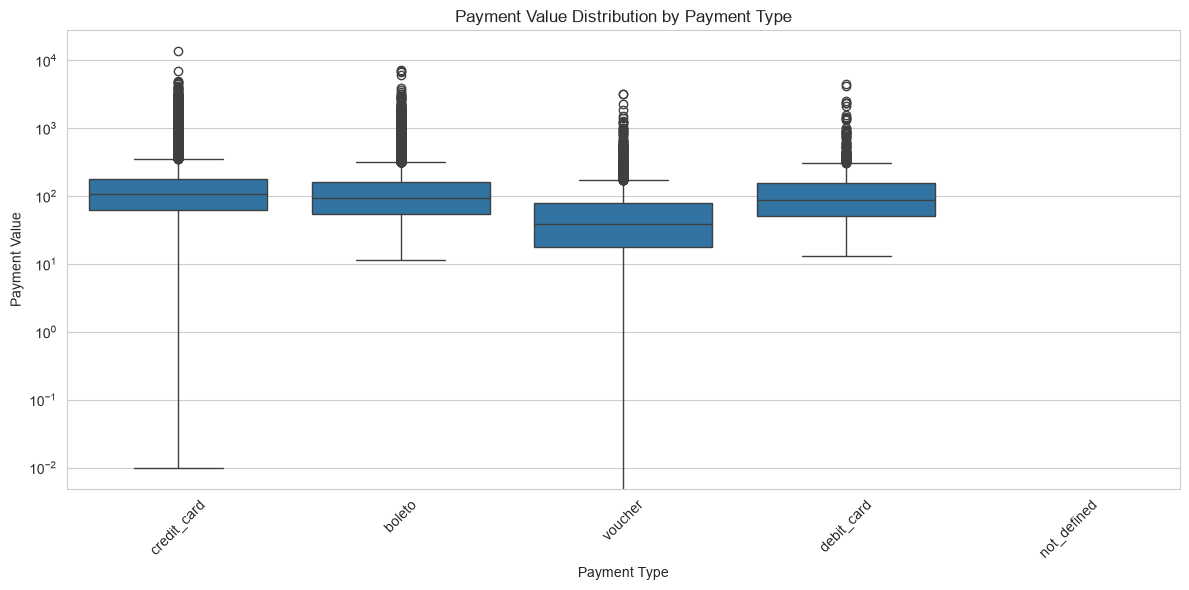

C:\Users\SKY PC\AppData\Local\Temp\ipykernel_4980\823785876.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=median_by_type.index, y=median_by_type.values, palette='viridis')


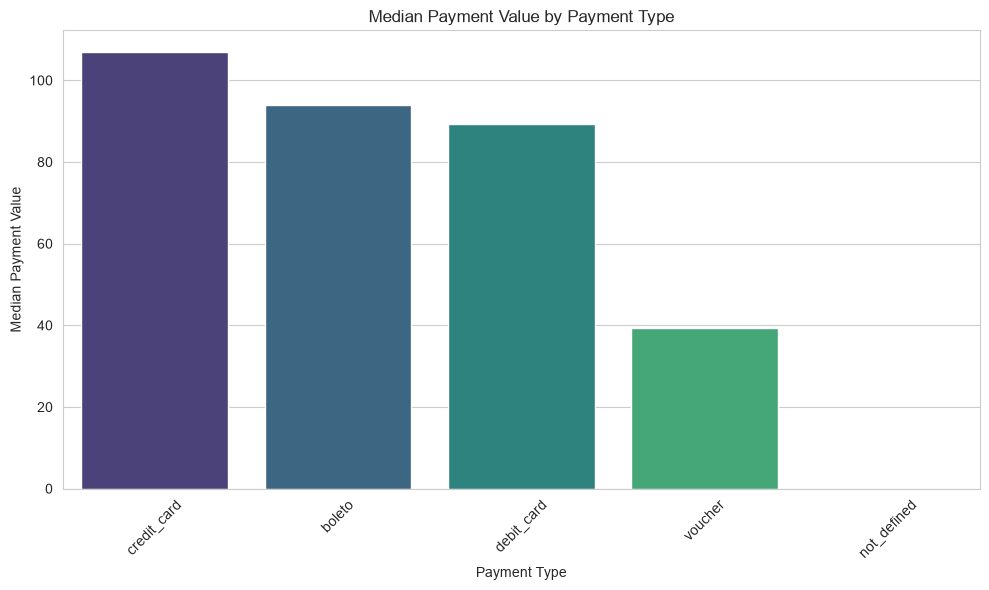

In [11]:
# Analyze payment value by payment type
payment_value_by_type = payments.groupby('payment_type')['payment_value'].describe()
print('Payment value statistics by payment type:')
display(payment_value_by_type)

plt.figure(figsize=(12, 6))
sns.boxplot(x='payment_type', y='payment_value', data=payments)
plt.title('Payment Value Distribution by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Payment Value')
plt.yscale('log')  # Log scale due to high skewness
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Median payment value by type
median_by_type = payments.groupby('payment_type')['payment_value'].median().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=median_by_type.index, y=median_by_type.values, palette='viridis')
plt.title('Median Payment Value by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Median Payment Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. EDA – Multiple Payment Methods Analysis

Orders with multiple payment methods: 2961
Percentage of orders with multiple payments: 2.98%

Distribution of number of payment methods per order:
1     96479
2      2382
3       301
4       108
5        52
6        36
7        28
8        11
9         9
10        5
11        8
12        8
13        3
14        2
15        2
19        2
21        1
22        1
26        1
29        1
Name: count, dtype: int64


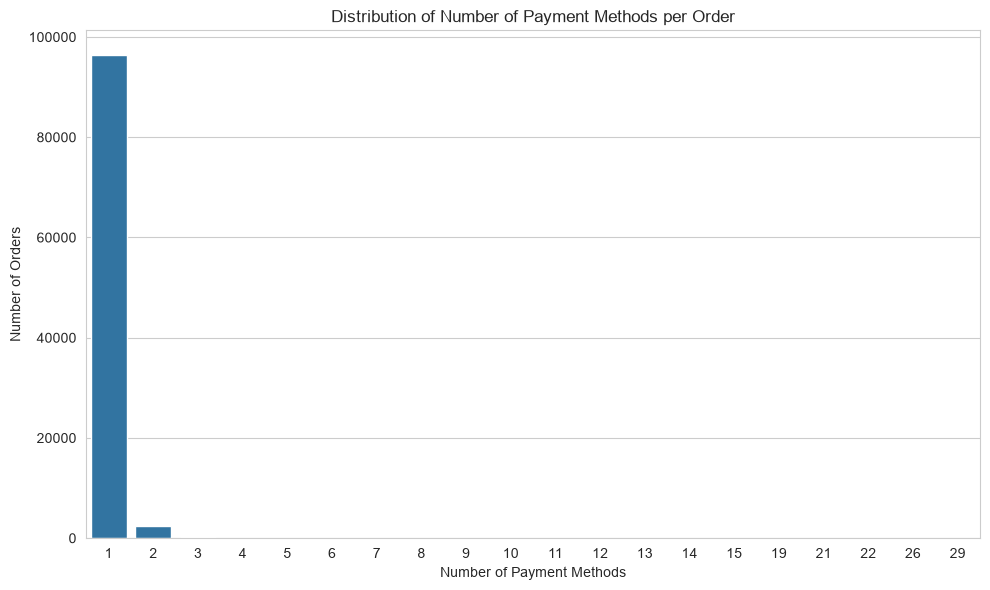


Most common payment type combinations:
payment_type
credit_card, voucher       2245
voucher                     427
credit_card                 287
credit_card, debit_card       1
debit_card                    1
Name: count, dtype: int64


In [12]:
# Detailed analysis of orders with multiple payment methods
multi_payment_orders = payments_per_order[payments_per_order > 1]
print(f'Orders with multiple payment methods: {len(multi_payment_orders)}')
print(f'Percentage of orders with multiple payments: {len(multi_payment_orders) / payments["order_id"].nunique() * 100:.2f}%')

print('\nDistribution of number of payment methods per order:')
print(payments_per_order.value_counts().sort_index())

plt.figure(figsize=(10, 6))
sns.countplot(x=payments_per_order)
plt.title('Distribution of Number of Payment Methods per Order')
plt.xlabel('Number of Payment Methods')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

# Analyze common combinations of payment types for multi-payment orders
multi_payment_data = payments[payments['order_id'].isin(multi_payment_orders.index)]
payment_combinations = multi_payment_data.groupby('order_id')['payment_type'].apply(lambda x: ', '.join(sorted(x.unique())))
print('\nMost common payment type combinations:')
print(payment_combinations.value_counts().head(10))

## 12. EDA – Payment Sequential Analysis

Payment sequential distribution:
count    103886.000000
mean          1.092679
std           0.706584
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          29.000000
Name: payment_sequential, dtype: float64


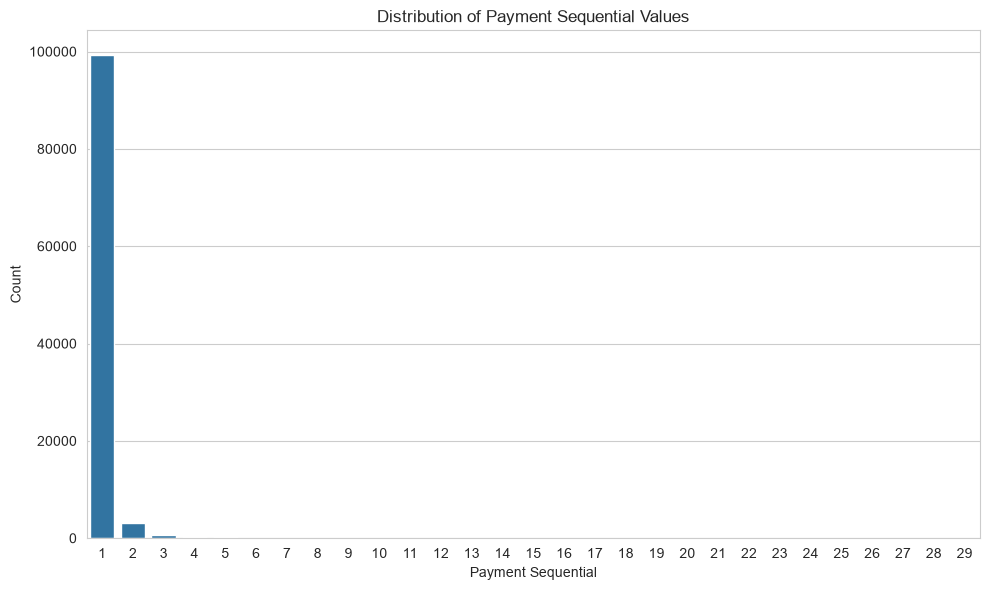


Payment sequential for orders with multiple payments:
payment_sequential
1     2959
2     2961
3      581
4      278
5      170
6      118
7       82
8       54
9       43
10      34
11      29
12      21
13      13
14      10
15       8
16       6
17       6
18       6
19       6
20       4
21       4
22       3
23       2
24       2
25       2
26       2
27       1
28       1
29       1
Name: count, dtype: int64


In [13]:
print('Payment sequential distribution:')
print(payments['payment_sequential'].describe())

plt.figure(figsize=(10, 6))
sns.countplot(x=payments['payment_sequential'])
plt.title('Distribution of Payment Sequential Values')
plt.xlabel('Payment Sequential')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Analyze payment sequential for multi-payment orders
multi_payment_data = payments[payments['order_id'].isin(multi_payment_orders.index)]
print('\nPayment sequential for orders with multiple payments:')
print(multi_payment_data['payment_sequential'].value_counts().sort_index())

## 13. EDA – Relationships and Correlations

Correlation matrix:


,payment_sequential,payment_installments,payment_value
payment_sequential,1.000000,-0.086363,-0.069593
payment_installments,-0.086363,1.000000,0.330811
payment_value,-0.069593,0.330811,1.000000


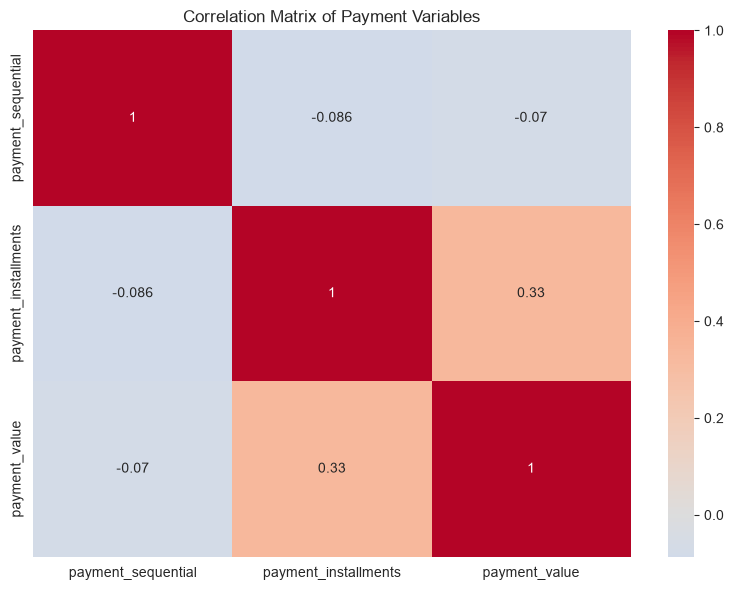

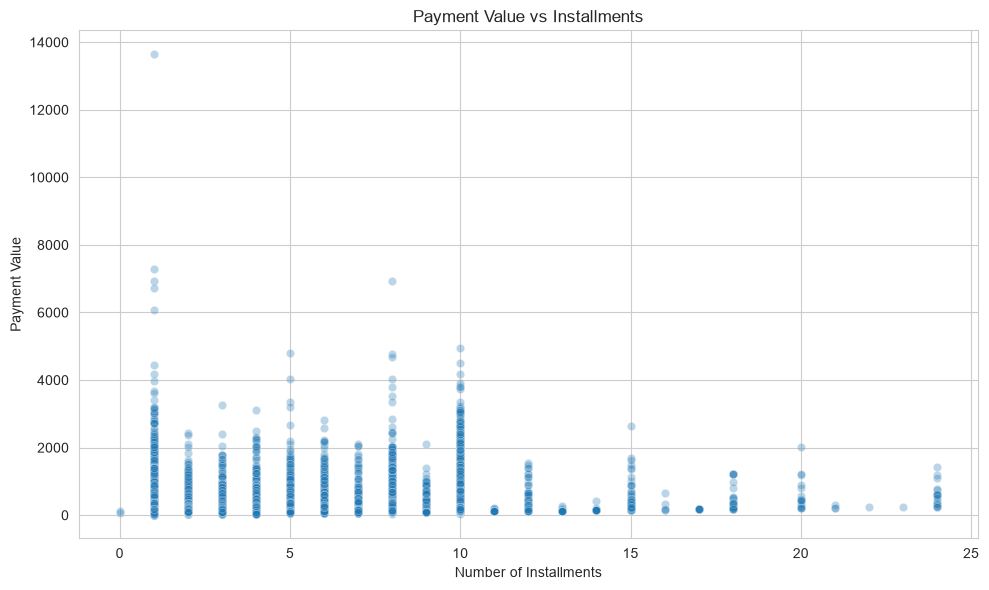

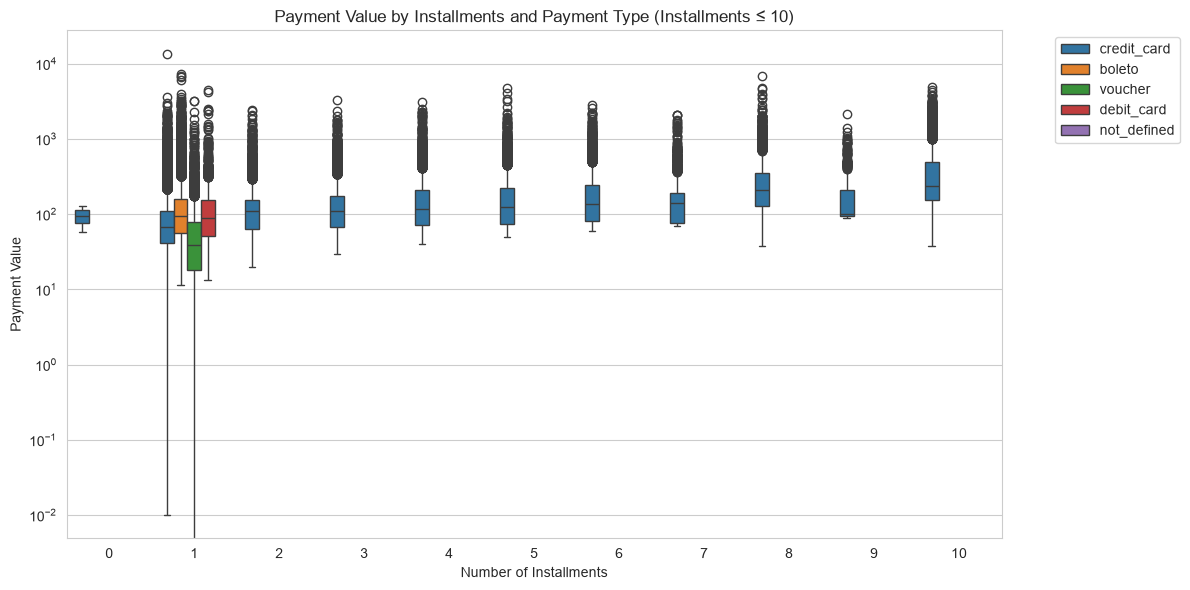

In [14]:
# Correlation between numerical variables
numeric_cols = ['payment_sequential', 'payment_installments', 'payment_value']
correlation_matrix = payments[numeric_cols].corr()
print('Correlation matrix:')
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Payment Variables')
plt.tight_layout()
plt.show()

# Scatter plot: Payment Value vs Installments
plt.figure(figsize=(10, 6))
sns.scatterplot(x='payment_installments', y='payment_value', data=payments, alpha=0.3)
plt.title('Payment Value vs Installments')
plt.xlabel('Number of Installments')
plt.ylabel('Payment Value')
plt.tight_layout()
plt.show()

# Payment value by installments for different payment types
plt.figure(figsize=(12, 6))
sns.boxplot(x='payment_installments', y='payment_value', hue='payment_type', data=payments[payments['payment_installments'] <= 10])
plt.title('Payment Value by Installments and Payment Type (Installments ≤ 10)')
plt.xlabel('Number of Installments')
plt.ylabel('Payment Value')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 14. EDA Findings Summary

In [15]:
# Summary of EDA findings that will inform preprocessing decisions
eda_findings = {
    "Data Quality": {
        "Missing Values": "None - all columns have complete data",
        "Duplicates": "No duplicate payment records found",
        "Invalid Values": "No negative values detected in payment fields"
    },
    "Payment Types": {
        "Distribution": "Credit card dominant (73.9%), followed by boleto (19.0%), voucher (5.6%), debit card (1.5%)",
        "Issue": "3 records with 'not_defined' payment type - negligible but needs handling",
        "Decision": "Treat 'not_defined' as 'other' category or drop these 3 records"
    },
    "Installments": {
        "Range": "0 to 24 installments, with most orders having 1 installment (no installments)",
        "Pattern": "Credit cards show highest installment counts, boleto typically has 0 installments",
        "Decision": "Create max_installments feature, consider installment flags"
    },
    "Payment Values": {
        "Distribution": "Highly right-skewed (skewness ~ high), most values under R$500",
        "Outliers": "Significant number of high-value transactions (extreme values present)",
        "Decision": "Keep raw values but create outlier flags; consider log transformation for modeling"
    },
    "Multiple Payments": {
        "Prevalence": f"{len(multi_payment_orders)} orders ({len(multi_payment_orders) / payments['order_id'].nunique() * 100:.2f}%) have multiple payment methods",
        "Pattern": "Most common: credit_card + voucher combinations",
        "Decision": "Aggregate to order level with payment method count and type flags"
    },
    "Feature Engineering Opportunities": {
        "Primary Features": ["total_payment_value", "payment_method_count", "primary_payment_type", "max_installments"],
        "Binary Flags": ["has_credit_card", "has_boleto", "has_voucher", "has_debit_card"],
        "Derived Features": ["average_payment_value", "installment_ratio", "is_high_value_order"]
    }
}

print("EDA FINDINGS SUMMARY")
print("=" * 50)
for category, findings in eda_findings.items():
    print(f"\n{category}:")
    for key, value in findings.items():
        print(f"  {key}: {value}")

EDA FINDINGS SUMMARY

Data Quality:
  Missing Values: None - all columns have complete data
  Duplicates: No duplicate payment records found
  Invalid Values: No negative values detected in payment fields

Payment Types:
  Distribution: Credit card dominant (73.9%), followed by boleto (19.0%), voucher (5.6%), debit card (1.5%)
  Issue: 3 records with 'not_defined' payment type - negligible but needs handling
  Decision: Treat 'not_defined' as 'other' category or drop these 3 records

Installments:
  Range: 0 to 24 installments, with most orders having 1 installment (no installments)
  Pattern: Credit cards show highest installment counts, boleto typically has 0 installments
  Decision: Create max_installments feature, consider installment flags

Payment Values:
  Distribution: Highly right-skewed (skewness ~ high), most values under R$500
  Outliers: Significant number of high-value transactions (extreme values present)
  Decision: Keep raw values but create outlier flags; consider log

---

## STAGE 4: Data Preprocessing and Feature Engineering

## 15. Data Cleaning

In [16]:
# Handle 'not_defined' payment type (3 records) - replace with 'other'
payments_clean = payments.copy()
payments_clean['payment_type'] = payments_clean['payment_type'].replace('not_defined', 'other')

print(f"Replaced 'not_defined' with 'other'")
print(f"Payment type distribution after cleaning:")
print(payments_clean['payment_type'].value_counts())

# Verify no negative values remain
print(f"\nData quality check after cleaning:")
print(f"Negative payment values: {(payments_clean['payment_value'] < 0).sum()}")
print(f"Negative installments: {(payments_clean['payment_installments'] < 0).sum()}")

Replaced 'not_defined' with 'other'
Payment type distribution after cleaning:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
other              3
Name: count, dtype: int64

Data quality check after cleaning:
Negative payment values: 0
Negative installments: 0


## 16. Payment Value Outlier Detection

In [17]:
def iqr_outlier_flag(series):
    """Create outlier flags using IQR method"""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).astype(int)

# Create outlier flags at payment record level
payments_clean['is_payment_value_outlier'] = iqr_outlier_flag(payments_clean['payment_value'])

print("Payment value outlier analysis:")
print(f"Outlier payment records: {payments_clean['is_payment_value_outlier'].sum()}")
print(f"Percentage of outliers: {payments_clean['is_payment_value_outlier'].mean() * 100:.2f}%")

# Show outlier thresholds
q1, q3 = payments_clean['payment_value'].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"\nOutlier thresholds:")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")

Payment value outlier analysis:
Outlier payment records: 7981
Percentage of outliers: 7.68%

Outlier thresholds:
Lower bound: -115.78
Upper bound: 344.41
Q1: 56.79, Q3: 171.84, IQR: 115.05


## 17. Order-Level Aggregation and Feature Engineering

In [18]:
# Function to determine primary payment type (the one with highest payment value)
def get_primary_payment_type(group):
    if len(group) == 1:
        return group['payment_type'].iloc[0]
    else:
        # Return the payment type with the highest value
        max_idx = group['payment_value'].idxmax()
        return group.loc[max_idx, 'payment_type']

# Aggregate payment data to order level
order_payment_features = (
    payments_clean
    .groupby('order_id')
    .agg(
        # Primary aggregations
        total_payment_value=('payment_value', 'sum'),
        payment_record_count=('payment_value', 'count'),   # number of raw payment rows for this order
        payment_method_count=('payment_type', 'nunique'),
        max_installments=('payment_installments', 'max'),
        total_installments=('payment_installments', 'sum'),

        # Outlier counts
        outlier_payment_count=('is_payment_value_outlier', 'sum'),
    )
    .reset_index()
)

# Create binary flags for each payment type
# FIX: the previous groupby(...).apply(lambda: pd.Series({...})) produced a long/stacked
# result (one row PER FLAG per order) instead of one row per order with flag columns,
# which caused a 5x row blow-up on merge (caught by the assertion in Section 19).
# pd.get_dummies + groupby().max() avoids that trap and gives one row per order directly.
payment_type_dummies = pd.get_dummies(payments_clean['payment_type']).add_prefix('has_')
payment_type_dummies['order_id'] = payments_clean['order_id']
payment_type_flags = (
    payment_type_dummies
    .groupby('order_id')
    .max()
    .astype(int)
    .reset_index()
)

# Get primary payment type for each order
primary_payment_type = (
    payments_clean
    .groupby('order_id')
    .apply(get_primary_payment_type)
    .reset_index()
)
primary_payment_type.columns = ['order_id', 'primary_payment_type']

# Merge all features together
order_payment_features = order_payment_features.merge(payment_type_flags, on='order_id', how='left')
order_payment_features = order_payment_features.merge(primary_payment_type, on='order_id', how='left')

# Derived features
# average_payment_value: true average per PAYMENT TRANSACTION (uses payment_record_count),
# not per distinct payment method — a single method paid across multiple installments/records
# would otherwise be miscounted as one "method" and inflate the average.
order_payment_features['average_payment_value'] = (
    order_payment_features['total_payment_value'] / order_payment_features['payment_record_count']
)

# installment_ratio: max installments relative to how many distinct payment methods were used.
# Kept as an exploratory feature — be ready to justify this in the viva, or drop it if it
# doesn't prove useful in feature selection (Stage 4 later).
order_payment_features['installment_ratio'] = (
    order_payment_features['max_installments'] / order_payment_features['payment_method_count']
).fillna(0)  # Handle division by zero

# High-value order flag (above 75th percentile)
high_value_threshold = order_payment_features['total_payment_value'].quantile(0.75)
order_payment_features['is_high_value_order'] = (
    order_payment_features['total_payment_value'] > high_value_threshold
).astype(int)

print("Order-level payment features shape:", order_payment_features.shape)
print("\nFirst few rows:")
display(order_payment_features.head())


Order-level payment features shape: (99440, 16)

First few rows:


,order_id,total_payment_value,payment_record_count,payment_method_count,max_installments,total_installments,outlier_payment_count,has_boleto,has_credit_card,has_debit_card,has_other,has_voucher,primary_payment_type,average_payment_value,installment_ratio,is_high_value_order
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,1,2,2,0,0,1,0,0,0,credit_card,72.19,2.0,0
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,1,3,3,0,0,1,0,0,0,credit_card,259.83,3.0,1
2,000229ec398224ef6ca0657da4fc703e,216.87,1,1,5,5,0,0,1,0,0,0,credit_card,216.87,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,1,2,2,0,0,1,0,0,0,credit_card,25.78,2.0,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,1,3,3,0,0,1,0,0,0,credit_card,218.04,3.0,1


## 18. Final Feature Set Documentation

In [19]:
print("FINAL PAYMENT FEATURES:")
print("=" * 50)
for i, col in enumerate(order_payment_features.columns, 1):
    print(f"{i}. {col}")

print("\nFEATURE DESCRIPTIONS:")
feature_descriptions = {
    "order_id": "Unique identifier for each order",
    "total_payment_value": "Sum of all payment values for the order",
    "payment_method_count": "Number of distinct payment methods used",
    "max_installments": "Maximum number of installments across all payment methods",
    "total_installments": "Sum of installments across all payment methods",
    "payment_record_count": "Number of raw payment records (transactions) for the order",
    "outlier_payment_count": "Number of payment records flagged as outliers",
    "has_credit_card": "Binary flag (1 if credit card was used)",
    "has_boleto": "Binary flag (1 if boleto was used)",
    "has_voucher": "Binary flag (1 if voucher was used)",
    "has_debit_card": "Binary flag (1 if debit card was used)",
    "has_other": "Binary flag (1 if 'other' payment type was used)",
    "primary_payment_type": "Payment type with the highest value for the order",
    "average_payment_value": "Average payment value per payment TRANSACTION (total_payment_value / payment_record_count)",
    "installment_ratio": "Max installments divided by payment method count",
    "is_high_value_order": "Binary flag (1 if total payment value > 75th percentile)"
}

for feature, description in feature_descriptions.items():
    print(f"{feature}: {description}")

FINAL PAYMENT FEATURES:
1. order_id
2. total_payment_value
3. payment_record_count
4. payment_method_count
5. max_installments
6. total_installments
7. outlier_payment_count
8. has_boleto
9. has_credit_card
10. has_debit_card
11. has_other
12. has_voucher
13. primary_payment_type
14. average_payment_value
15. installment_ratio
16. is_high_value_order

FEATURE DESCRIPTIONS:
order_id: Unique identifier for each order
total_payment_value: Sum of all payment values for the order
payment_method_count: Number of distinct payment methods used
max_installments: Maximum number of installments across all payment methods
total_installments: Sum of installments across all payment methods
payment_record_count: Number of raw payment records (transactions) for the order
outlier_payment_count: Number of payment records flagged as outliers
has_credit_card: Binary flag (1 if credit card was used)
has_boleto: Binary flag (1 if boleto was used)
has_voucher: Binary flag (1 if voucher was used)
has_debit_ca

## 19. Final Quality Checks

In [20]:
# One row per order
print("Rows:", len(order_payment_features))
print("Unique order IDs:", order_payment_features["order_id"].nunique())
assert len(order_payment_features) == order_payment_features["order_id"].nunique(), "Error: Duplicate order IDs found"

# Duplicate order IDs
print("Duplicate order IDs:", order_payment_features.duplicated(subset=["order_id"]).sum())

# Missing values
print("\nMissing values:")
print(order_payment_features.isnull().sum())

# Numerical summary
print("\nNumerical summary:")
display(order_payment_features.describe())

# Basic invalid-value checks
print("\nInvalid value checks:")
print("Negative total payment value:", (order_payment_features["total_payment_value"] < 0).sum())
print("Negative max installments:", (order_payment_features["max_installments"] < 0).sum())
print("Negative average payment value:", (order_payment_features["average_payment_value"] < 0).sum())

# Data type checks
print("\nData types:")
print(order_payment_features.dtypes)

# Primary payment type distribution
print("\nPrimary payment type distribution:")
print(order_payment_features["primary_payment_type"].value_counts())

Rows: 99440
Unique order IDs: 99440
Duplicate order IDs: 0

Missing values:
order_id                 0
total_payment_value      0
payment_record_count     0
payment_method_count     0
max_installments         0
total_installments       0
outlier_payment_count    0
has_boleto               0
has_credit_card          0
has_debit_card           0
has_other                0
has_voucher              0
primary_payment_type     0
average_payment_value    0
installment_ratio        0
is_high_value_order      0
dtype: int64

Numerical summary:


,total_payment_value,payment_record_count,payment_method_count,max_installments,total_installments,outlier_payment_count,has_boleto,has_credit_card,has_debit_card,has_other,has_voucher,average_payment_value,installment_ratio,is_high_value_order
count,99440.000000,99440.000000,99440.000000,99440.000000,99440.000000,99440.000000,99440.000000,99440.000000,99440.000000,99440.000000,99440.000000,99440.000000,99440.000000,99440.000000
mean,160.990267,1.044710,1.022586,2.930521,2.980923,0.080259,0.198954,0.769358,0.015366,0.000030,0.038878,158.317915,2.905908,0.249990
std,221.951257,0.381166,0.148582,2.715685,2.741810,0.273025,0.399215,0.421246,0.123004,0.005493,0.193304,219.194549,2.708737,0.433009
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,62.010000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,60.190000,1.000000,0.000000
50%,105.290000,1.000000,1.000000,2.000000,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,103.330000,2.000000,0.000000
75%,176.970000,1.000000,1.000000,4.000000,4.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,174.990000,4.000000,0.000000
max,13664.080000,29.000000,2.000000,24.000000,29.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,13664.080000,24.000000,1.000000



Invalid value checks:
Negative total payment value: 0
Negative max installments: 0
Negative average payment value: 0

Data types:
order_id                     str
total_payment_value      float64
payment_record_count       int64
payment_method_count       int64
max_installments           int64
total_installments         int64
outlier_payment_count      int64
has_boleto                 int64
has_credit_card            int64
has_debit_card             int64
has_other                  int64
has_voucher                int64
primary_payment_type         str
average_payment_value    float64
installment_ratio        float64
is_high_value_order        int64
dtype: object

Primary payment type distribution:
primary_payment_type
credit_card    74975
boleto         19784
voucher         3151
debit_card      1527
other              3
Name: count, dtype: int64


## 20. Leakage Check

In [21]:
print("LEAKAGE CHECK:")
print("=" * 50)
print("✓ All payment features are derived from order-time information")
print("✓ No post-delivery fields (order_delivered_customer_date, order_status, etc.) are included")
print("✓ Payment information is available at order placement time")
print("✓ All features are safe for predictive modeling")

# Verify we only have order-level data
print("\nFeature leakage verification:")
print(f"- All features are based on: payment_type, payment_value, payment_installments (all available at order time)")
print(f"- No features use: delivery dates, order status, review scores, or other post-dispatch information")
print(f"- Aggregation is performed at order level only, preserving order-time context")

LEAKAGE CHECK:
✓ All payment features are derived from order-time information
✓ No post-delivery fields (order_delivered_customer_date, order_status, etc.) are included
✓ Payment information is available at order placement time
✓ All features are safe for predictive modeling

Feature leakage verification:
- All features are based on: payment_type, payment_value, payment_installments (all available at order time)
- No features use: delivery dates, order status, review scores, or other post-dispatch information
- Aggregation is performed at order level only, preserving order-time context


## 21. Save the Member D Deliverable

In [22]:
import os

# Ensure the directory exists
os.makedirs('../data/processed', exist_ok=True)

# Save the processed payment features
order_payment_features.to_csv(
    "../data/processed/payments_clean.csv", index=False
)

# Verify the saved file
saved = pd.read_csv("../data/processed/payments_clean.csv")
print("✓ Successfully saved payments_clean.csv")
print(f"Saved shape: {saved.shape}")
print(f"Columns: {saved.columns.tolist()}")
print("\nFirst few rows of saved file:")
display(saved.head())

print("\n" + "="*50)
print("MEMBER D PAYMENTS PREPROCESSING COMPLETE")
print("="*50)
print(f"✓ Processed {len(order_payment_features)} orders")
print(f"✓ Created {len(order_payment_features.columns)} features")
print(f"✓ Output saved to: data/processed/payments_clean.csv")
print("✓ Ready for final merge in notebook 05")

✓ Successfully saved payments_clean.csv
Saved shape: (99440, 16)
Columns: ['order_id', 'total_payment_value', 'payment_record_count', 'payment_method_count', 'max_installments', 'total_installments', 'outlier_payment_count', 'has_boleto', 'has_credit_card', 'has_debit_card', 'has_other', 'has_voucher', 'primary_payment_type', 'average_payment_value', 'installment_ratio', 'is_high_value_order']

First few rows of saved file:


,order_id,total_payment_value,payment_record_count,payment_method_count,max_installments,total_installments,outlier_payment_count,has_boleto,has_credit_card,has_debit_card,has_other,has_voucher,primary_payment_type,average_payment_value,installment_ratio,is_high_value_order
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,1,2,2,0,0,1,0,0,0,credit_card,72.19,2.0,0
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,1,3,3,0,0,1,0,0,0,credit_card,259.83,3.0,1
2,000229ec398224ef6ca0657da4fc703e,216.87,1,1,5,5,0,0,1,0,0,0,credit_card,216.87,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,1,2,2,0,0,1,0,0,0,credit_card,25.78,2.0,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,1,3,3,0,0,1,0,0,0,credit_card,218.04,3.0,1



MEMBER D PAYMENTS PREPROCESSING COMPLETE
✓ Processed 99440 orders
✓ Created 16 features
✓ Output saved to: data/processed/payments_clean.csv
✓ Ready for final merge in notebook 05
